In [1]:
# Reproducible, Colab-safe setup
import importlib.util, subprocess, sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

required = {"mlxtend": "mlxtend", "wordcloud": "wordcloud", "psutil": "psutil"}
missing = [pkg for pkg, module in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="deep")
OUTPUT_DIR = Path("Output_Screenshots")
OUTPUT_DIR.mkdir(exist_ok=True)

def save_table_image(frame, filename, title, max_rows=12):
    shown = frame.head(max_rows).copy()
    fig_h = max(2.6, 0.38 * (len(shown) + 2))
    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.axis("off")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    table = ax.table(cellText=shown.values, colLabels=shown.columns,
                     cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.35)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#1f4e79")
            cell.set_text_props(color="white", weight="bold")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

Dataset: 3500 transactions, 35 possible items


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Transaction_ID,Products
0,1,"Item_00, Item_01, Item_02, Item_14, Item_20, I..."
1,2,"Item_00, Item_01, Item_02, Item_25, Item_26, I..."
2,3,"Item_10, Item_11, Item_12, Item_29"
3,4,"Item_06, Item_10, Item_11, Item_12, Item_32"
4,5,"Item_07, Item_10, Item_11, Item_12, Item_14, I..."
5,6,"Item_00, Item_01, Item_02, Item_05, Item_09, I..."
6,7,"Item_00, Item_01, Item_02, Item_14, Item_23, I..."
7,8,"Item_01, Item_10, Item_11, Item_12, Item_19"
8,9,"Item_12, Item_20, Item_21, Item_25, Item_30"
9,10,"Item_02, Item_05, Item_06, Item_11, Item_15, I..."


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

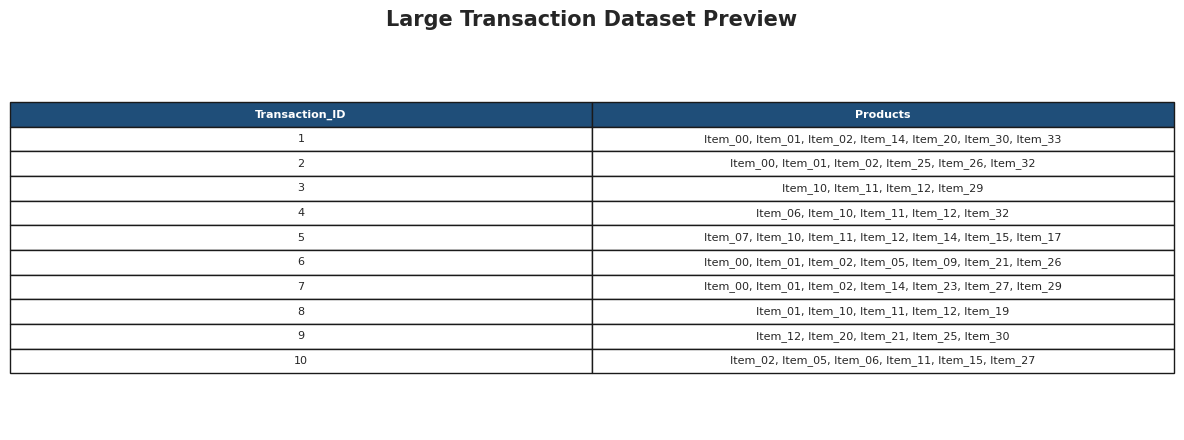

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [2]:
import time, tracemalloc
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori,fpgrowth

items=[f"Item_{i:02d}" for i in range(35)]
patterns=[["Item_00","Item_01","Item_02"],["Item_05","Item_06"],["Item_10","Item_11","Item_12"],
          ["Item_20","Item_21"],["Item_25","Item_26","Item_27"]]
transactions=[]
for _ in range(3500):
    basket=set(patterns[rng.integers(len(patterns))])
    basket.update(rng.choice(items,size=rng.integers(1,5),replace=False))
    transactions.append(sorted(basket))
preview=pd.DataFrame({"Transaction_ID":range(1,11),"Products":[", ".join(x) for x in transactions[:10]]})
print(f"Dataset: {len(transactions)} transactions, {len(items)} possible items")
display(preview); save_table_image(preview,"01_dataset_preview.png","Large Transaction Dataset Preview")
te=TransactionEncoder(); encoded=pd.DataFrame(te.fit(transactions).transform(transactions),columns=te.columns_)

In [3]:
def benchmark(func,name,min_support=.035):
    tracemalloc.start(); start=time.perf_counter()
    result=func(encoded,min_support=min_support,use_colnames=True,max_len=3)
    elapsed=time.perf_counter()-start
    _,peak=tracemalloc.get_traced_memory(); tracemalloc.stop()
    canonical=set((tuple(sorted(x)),round(float(s),8)) for x,s in zip(result.itemsets,result.support))
    return result,{"Algorithm":name,"Time_seconds":elapsed,"Itemsets":len(result),"Peak_memory_MB":peak/1024**2},canonical

ap,ap_stats,ap_set=benchmark(apriori,"Apriori")
fp,fp_stats,fp_set=benchmark(fpgrowth,"FP-Growth")
comparison=pd.DataFrame([ap_stats,fp_stats])
consistent=ap_set==fp_set
display(comparison.round(4)); print("Output consistency:",consistent)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Algorithm,Time_seconds,Itemsets,Peak_memory_MB
0,Apriori,0.0514,51,6.0076
1,FP-Growth,4.4346,51,2.2015


Output consistency: True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

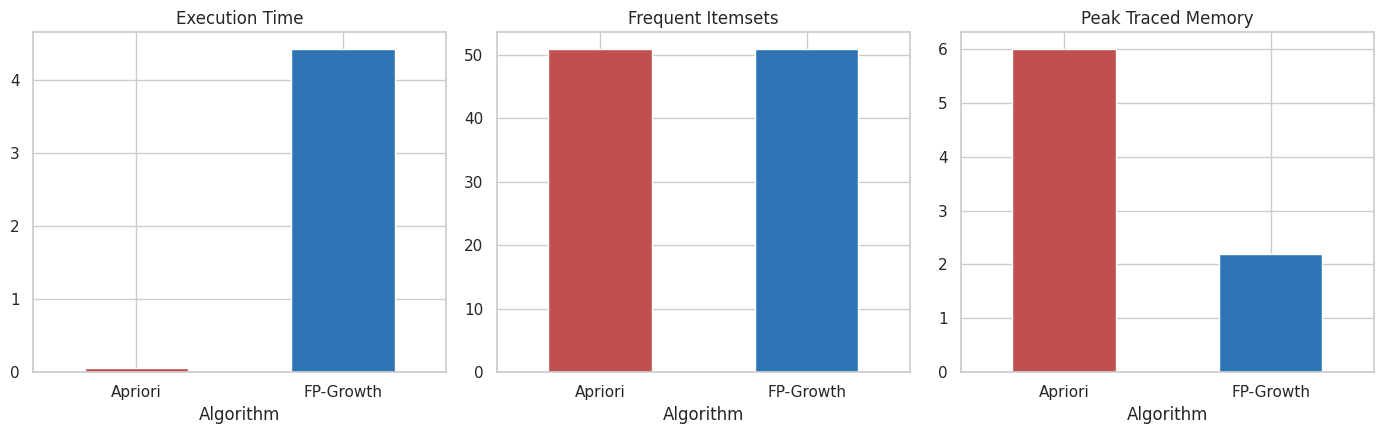

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Conclusion: Apriori was faster for this dataset. FP-Growth generally scales better for dense data; Apriori remains easy to interpret for smaller sparse data.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

387

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
fig,axes=plt.subplots(1,3,figsize=(14,4.5))
comparison.plot.bar(x="Algorithm",y="Time_seconds",legend=False,ax=axes[0],color=["#c0504d","#2f75b5"]); axes[0].set_title("Execution Time")
comparison.plot.bar(x="Algorithm",y="Itemsets",legend=False,ax=axes[1],color=["#c0504d","#2f75b5"]); axes[1].set_title("Frequent Itemsets")
comparison.plot.bar(x="Algorithm",y="Peak_memory_MB",legend=False,ax=axes[2],color=["#c0504d","#2f75b5"]); axes[2].set_title("Peak Traced Memory")
for ax in axes: ax.tick_params(axis="x",rotation=0)
fig.tight_layout(); fig.savefig(OUTPUT_DIR/"02_results.png",dpi=180,bbox_inches="tight"); plt.show()
faster=comparison.sort_values("Time_seconds").iloc[0].Algorithm
print(f"Conclusion: {faster} was faster for this dataset. FP-Growth generally scales better for dense data; Apriori remains easy to interpret for smaller sparse data.")
metrics={"rows":len(transactions),"columns":len(items),"min_support":.035,
         "comparison":comparison.round(6).to_dict("records"),"consistent":consistent,"faster":faster}
Path("results.json").write_text(json.dumps(metrics,indent=2))